# 📊 State of Data Brazil 2024–2025
## Quais fatores mais influenciam o salário de um profissional de dados no Brasil?

**Disciplina:** Análise Avançada de Dados — UNIFSA  
**Professora:** Ma. Heloísa Guimarães  
**Base de dados:** [State of Data Brazil 2024–2025 — Kaggle](https://www.kaggle.com/datasets/datahackers/state-of-data-brazil-20242025)  
**Fonte:** Data Hackers + Bain & Company | 5.216 respondentes | 403 colunas

---

### Pergunta Central
> *"Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?"*

Toda análise, todo gráfico e toda conclusão deste notebook responde direta ou indiretamente a essa pergunta.

---

---
## ETAPA 1 — Carregamento e Reconhecimento dos Dados

### Raciocínio
Antes de qualquer análise, precisamos conhecer o que temos: quantas linhas, quantas colunas, quais os tipos de dados, onde estão os valores ausentes. Este reconhecimento inicial guia todas as decisões de limpeza e evita erros por suposições equivocadas sobre os dados.

O dataset possui **403 colunas** com nomes estruturados como `1.b_genero`, `2.h_faixa_salarial`, `4.d.3_Python` — já nomeados de forma legível. Renomearemos as mais críticas para nomes ainda mais curtos, facilitando o código.

In [26]:
# ── Importação das bibliotecas ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais globais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('✅ Bibliotecas importadas com sucesso.')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ Bibliotecas importadas com sucesso.
   pandas 2.2.2 | numpy 2.0.2


In [25]:
from google.colab import files

uploaded = files.upload()


Saving Final Dataset - State of Data 2024 - Kaggle - df_survey_2024 (1).csv to Final Dataset - State of Data 2024 - Kaggle - df_survey_2024 (1) (1).csv


In [27]:
import os

print(os.listdir())

['.config', 'Final Dataset - State of Data 2024 - Kaggle - df_survey_2024 (1) (1).csv', 'analise (1).ipynb', 'analise.ipynb', 'Final Dataset - State of Data 2024 - Kaggle - df_survey_2024 (1).csv', 'analise (2).ipynb', 'sample_data']


In [29]:
# ── Carregamento do CSV ──────────────────────────────────────────────────────
# Baixe o arquivo em: kaggle.com/datasets/datahackers/state-of-data-brazil-20242025
import pandas as pd

CSV_PATH = 'Final Dataset - State of Data 2024 - Kaggle - df_survey_2024 (1).csv'

df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print(f'Shape do dataset: {df_raw.shape}')
print(f'Linhas: {df_raw.shape[0]:,} | Colunas: {df_raw.shape[1]:,}')

Shape do dataset: (5217, 403)
Linhas: 5,217 | Colunas: 403


In [30]:
# ── Primeiras linhas ─────────────────────────────────────────────────────────
cols_preview = [
    '1.b_genero','1.c_cor/raca/etnia','1.i.2_regiao_onde_mora',
    '1.l_nivel_de_ensino','2.f_cargo_atual','2.g_nivel',
    '2.h_faixa_salarial','2.i_tempo_de_experiencia_em_dados'
]
df_raw[cols_preview].head(5)

,1.b_genero,1.c_cor/raca/etnia,1.i.2_regiao_onde_mora,1.l_nivel_de_ensino,2.f_cargo_atual,2.g_nivel,2.h_faixa_salarial,2.i_tempo_de_experiencia_em_dados
0,Masculino,Branca,Sul,Estudante de Graduação,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos
1,Masculino,Branca,Sul,Estudante de Graduação,Analista de BI/BI Analyst,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano
2,Masculino,Parda,Sudeste,Estudante de Graduação,Outra Opção,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Não tenho experiência na área de dados
3,Masculino,Branca,Sudeste,Estudante de Graduação,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano
4,Masculino,Branca,Sudeste,Estudante de Graduação,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano


In [31]:
# ── Análise de valores ausentes nas colunas-chave ────────────────────────────
colunas_chave = [
    '2.h_faixa_salarial', '2.g_nivel', '2.f_cargo_atual',
    '1.b_genero', '1.c_cor/raca/etnia', '1.l_nivel_de_ensino',
    '1.i.2_regiao_onde_mora', '2.i_tempo_de_experiencia_em_dados',
    '4.d.3_Python', '4.d.1_SQL'
]

nulos = df_raw[colunas_chave].isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(1)
pd.DataFrame({'Nulos': nulos, '% Ausente': pct}).sort_values('Nulos', ascending=False)

,Nulos,% Ausente
4.d.1_SQL,1628,31.2
4.d.3_Python,1628,31.2
2.f_cargo_atual,1399,26.8
2.g_nivel,1399,26.8
2.h_faixa_salarial,354,6.8
2.i_tempo_de_experiencia_em_dados,354,6.8
1.i.2_regiao_onde_mora,142,2.7
1.l_nivel_de_ensino,0,0.0
1.b_genero,0,0.0
1.c_cor/raca/etnia,0,0.0


### Renomeação das colunas principais

As colunas já têm nomes legíveis no dataset (ex: `2.h_faixa_salarial`), mas criamos aliases mais curtos para o código analítico. Mapeamento explícito abaixo:

| Coluna original | Alias curto | Significado |
|---|---|---|
| `1.b_genero` | `genero` | Gênero autodeclarado |
| `1.c_cor/raca/etnia` | `cor_raca` | Cor/Raça/Etnia autodeclarada |
| `1.i.2_regiao_onde_mora` | `regiao` | Região geográfica atual |
| `1.l_nivel_de_ensino` | `nivel_ensino` | Grau de escolaridade |
| `2.f_cargo_atual` | `cargo_atual` | Cargo/função atual |
| `2.g_nivel` | `senioridade` | Nível (Júnior/Pleno/Sênior) |
| `2.h_faixa_salarial` | `faixa_salarial` | Faixa de remuneração mensal |
| `2.i_tempo_de_experiencia_em_dados` | `tempo_experiencia` | Tempo de atuação em dados |
| `2.c_numero_de_funcionarios` | `tamanho_empresa` | Porte da organização |
| `2.b_setor` | `setor_empresa` | Setor de atuação |
| `4.d.3_Python` | `usa_python` | Usa Python no trabalho (0/1) |
| `4.d.1_SQL` | `usa_sql` | Usa SQL no trabalho (0/1) |
| `1.a_idade` | `idade` | Idade do respondente |
| `1.i.1_uf_onde_mora` | `uf` | Unidade Federativa |


In [32]:
# ── Renomeação das 14 colunas principais ─────────────────────────────────────
RENAME_MAP = {
    '1.b_genero'                            : 'genero',
    '1.c_cor/raca/etnia'                    : 'cor_raca',
    '1.i.2_regiao_onde_mora'                : 'regiao',
    '1.l_nivel_de_ensino'                   : 'nivel_ensino',
    '2.f_cargo_atual'                       : 'cargo_atual',
    '2.g_nivel'                             : 'senioridade',
    '2.h_faixa_salarial'                    : 'faixa_salarial',
    '2.i_tempo_de_experiencia_em_dados'     : 'tempo_experiencia',
    '2.c_numero_de_funcionarios'            : 'tamanho_empresa',
    '2.b_setor'                             : 'setor_empresa',
    '4.d.3_Python'                          : 'usa_python',
    '4.d.1_SQL'                             : 'usa_sql',
    '1.a_idade'                             : 'idade',
    '1.i.1_uf_onde_mora'                    : 'uf',
}

df = df_raw.rename(columns=RENAME_MAP).copy()
print(f'Colunas renomeadas: {len(RENAME_MAP)}')
print('Aliases criados:', list(RENAME_MAP.values()))

Colunas renomeadas: 14
Aliases criados: ['genero', 'cor_raca', 'regiao', 'nivel_ensino', 'cargo_atual', 'senioridade', 'faixa_salarial', 'tempo_experiencia', 'tamanho_empresa', 'setor_empresa', 'usa_python', 'usa_sql', 'idade', 'uf']


---
## ETAPA 2 — Limpeza e Decisões Documentadas

Identificamos cinco problemas principais neste dataset. Cada um é tratado abaixo com justificativa explícita e análise do impacto da decisão.

### 2.1 — Conversão de faixas salariais para ponto médio numérico

**Problema:** A coluna `faixa_salarial` é categórica textual (ex: `"de R$ 8.001/mês a R$ 12.000/mês"`). Sem conversão, é impossível calcular média, correlação ou qualquer estatística numérica.

**Solução:** Mapeamento explícito de cada categoria para o ponto médio aritmético da faixa. Faixas abertas ("Acima de R$ 40.001") recebem valor conservador de R$ 50.000.

**Limitações desta decisão:**
- Assume distribuição uniforme dentro de cada faixa, o que raramente é verdade
- Perde granularidade: todos dentro de `R$ 8.001–12.000` são tratados como `R$ 10.000`
- Faixas abertas são subestimadas (alguns ganham bem mais que R$ 50.000)
- **Por que mesmo assim é válido?** A faixa salarialmédio preserva a ordem relativa entre grupos, que é o que mais importa para comparações

In [33]:
# ── Mapeamento de faixas salariais → ponto médio ─────────────────────────────
SALARIO_MAP = {
    'Menos de R$ 1.000/mês'               :   500,
    'de R$ 1.001/mês a R$ 2.000/mês'      :  1500,
    'de R$ 2.001/mês a R$ 3.000/mês'      :  2500,
    'de R$ 3.001/mês a R$ 4.000/mês'      :  3500,
    'de R$ 4.001/mês a R$ 6.000/mês'      :  5000,
    'de R$ 6.001/mês a R$ 8.000/mês'      :  7000,
    'de R$ 8.001/mês a R$ 12.000/mês'     : 10000,
    'de R$ 12.001/mês a R$ 16.000/mês'    : 14000,
    'de R$ 16.001/mês a R$ 20.000/mês'    : 18000,
    'de R$ 20.001/mês a R$ 25.000/mês'    : 22500,
    'de R$ 25.001/mês a R$ 30.000/mês'    : 27500,
    'de R$ 30.001/mês a R$ 40.000/mês'    : 35000,
    'Acima de R$ 40.001/mês'              : 50000,
}

df['salario_medio'] = df['faixa_salarial'].map(SALARIO_MAP)

print('Resultado da conversão:')
print(f'  Convertidos com sucesso: {df["salario_medio"].notna().sum():,}')
print(f'  Não convertidos (NaN): {df["salario_medio"].isna().sum():,} '
      f'({df["salario_medio"].isna().mean()*100:.1f}%)')
print('\nDistribuição dos pontos médios:')
df['salario_medio'].value_counts().sort_index()

Resultado da conversão:
  Convertidos com sucesso: 4,863
  Não convertidos (NaN): 354 (6.8%)

Distribuição dos pontos médios:


,count
salario_medio,
500.0,33
1500.0,155
2500.0,237
3500.0,270
5000.0,593
7000.0,656
10000.0,1080
14000.0,716
18000.0,456


### 2.2 — Tratamento de valores ausentes

**Decisão para cada campo:**

| Campo | Nulos | Decisão | Justificativa |
|---|---|---|---|
| `faixa_salarial` | 354 (6,8%) | Excluir da análise salarial | Sem salário não é possível analisar o determinante |
| `senioridade` | 1.399 (26,8%) | Manter como categoria 'Não informado' | Coincide com ausência de cargo — provavelmente respondentes fora da área |
| `cargo_atual` | 1.399 (26,8%) | Manter como 'Não informado' | Idem |
| `genero` | 0 (0%) | Sem ação necessária | Todos responderam |
| `cor_raca` | 0 (0%) | Sem ação necessária | Todos responderam |
| `usa_python` / `usa_sql` | 1.628 (31,2%) | NaN → 0 | Perguntas de ferramentas: quem não marcou não usa |

**Decisão ética crítica:** Os campos `genero` e `cor_raca` não têm NaN reais, mas têm respostas como 'Prefiro não informar'. Essas respostas **não serão imputadas** e serão excluídas das análises de equidade — elas representam escolha consciente do respondente.

In [34]:
# ── Criação do dataset de trabalho ───────────────────────────────────────────
df_sal = df[df['salario_medio'].notna()].copy()
print(f'Dataset de trabalho: {len(df_sal):,} respondentes com salário informado')
print(f'Excluídos por ausência de salário: {len(df) - len(df_sal):,}')

# Ferramentas binárias: NaN → 0
df_sal['usa_python'] = df_sal['usa_python'].fillna(0).astype(int)
df_sal['usa_sql']    = df_sal['usa_sql'].fillna(0).astype(int)

# Flag: prefiro não informar em gênero/raça (excluir dessas análises)
generos_validos = ['Masculino', 'Feminino']
racas_validas   = ['Branca', 'Parda', 'Preta', 'Amarela', 'Indígena']

print(f'\nRespondentes com gênero informado (M/F): {df_sal["genero"].isin(generos_validos).sum():,}')
print(f'Respondentes com raça informada: {df_sal["cor_raca"].isin(racas_validas).sum():,}')

Dataset de trabalho: 4,863 respondentes com salário informado
Excluídos por ausência de salário: 354

Respondentes com gênero informado (M/F): 4,842
Respondentes com raça informada: 4,822


### 2.3 — Padronização de cargos

**Problema:** O campo `cargo_atual` já vem padronizado neste dataset (diferente de edições anteriores). Cada respondente escolheu de uma lista fechada, então não há variações de digitação.

**Decisão:** Criar uma coluna de **cargo_grupo** que agrupa cargos similares para análise comparativa.

| Cargos originais | Grupo |
|---|---|
| Analista de Dados/Data Analyst | Analista de Dados |
| Analista de BI/BI Analyst | BI / Analytics |
| Analytics Engineer | BI / Analytics |
| Cientista de Dados/Data Scientist | Cientista de Dados |
| Engenheiro de Dados/Data Engineer | Engenheiro de Dados |
| Engenheiro de ML/ML Engineer/AI Engineer | ML / AI Engineer |
| Arquiteto de Dados | ML / AI Engineer |
| Data Product Manager | Gestão / Produto |


In [35]:
# ── Agrupamento de cargos ─────────────────────────────────────────────────────
CARGO_GRUPO = {
    'Analista de Dados/Data Analyst'                                : 'Analista de Dados',
    'Analista de BI/BI Analyst'                                     : 'BI / Analytics',
    'Analytics Engineer'                                            : 'BI / Analytics',
    'Analista de Negócios/Business Analyst'                         : 'BI / Analytics',
    'Cientista de Dados/Data Scientist'                             : 'Cientista de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect'              : 'Engenheiro de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer'        : 'ML / AI Engineer',
    'Arquiteto de Dados/Data Architect'                             : 'ML / AI Engineer',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)'    : 'Gestão / Produto',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas'   : 'Desenvolvimento',
    'Analista de Suporte/Analista Técnico'                          : 'Suporte / Técnico',
    'Outra Opção'                                                   : 'Outros',
}

df_sal['cargo_grupo'] = df_sal['cargo_atual'].map(CARGO_GRUPO).fillna('Outros')

print('Distribuição por grupo de cargo:')
print(df_sal['cargo_grupo'].value_counts())

Distribuição por grupo de cargo:
cargo_grupo
Outros                 1366
Analista de Dados       957
BI / Analytics          808
Cientista de Dados      687
Engenheiro de Dados     613
ML / AI Engineer        151
Desenvolvimento         122
Gestão / Produto         80
Suporte / Técnico        79
Name: count, dtype: int64


In [36]:
# ── Codificação ordinal do tempo de experiência ───────────────────────────────
TEMPO_MAP = {
    'Não tenho experiência na área de dados': 0,
    'Menos de 1 ano'   : 0.5,
    'de 1 a 2 anos'    : 1.5,
    'de 3 a 4 anos'    : 3.5,
    'de 5 a 6 anos'    : 5.5,
    'de 7 a 10 anos'   : 8.5,
    'Mais de 10 anos'  : 12.0,
}
df_sal['tempo_exp_num'] = df_sal['tempo_experiencia'].map(TEMPO_MAP)

print('Codificação ordinal do tempo de experiência:')
print(df_sal['tempo_experiencia'].value_counts())

Codificação ordinal do tempo de experiência:
tempo_experiencia
de 3 a 4 anos                             1386
de 1 a 2 anos                              944
de 5 a 6 anos                              830
Mais de 10 anos                            585
de 7 a 10 anos                             542
Menos de 1 ano                             346
Não tenho experiência na área de dados     230
Name: count, dtype: int64


In [37]:
# ── Resumo final do dataset limpo ─────────────────────────────────────────────
print('=' * 55)
print('   DATASET APÓS LIMPEZA — PRONTO PARA ANÁLISE')
print('=' * 55)
print(f'  Total de respondentes analisados : {len(df_sal):,}')
print(f'  Colunas no dataset               : {df_sal.shape[1]}')
print(f'  Salário médio (ponto médio)      : R$ {df_sal["salario_medio"].mean():,.0f}')
print(f'  Salário mediano                  : R$ {df_sal["salario_medio"].median():,.0f}')
print(f'  % que usa Python                 : {df_sal["usa_python"].mean()*100:.1f}%')
print(f'  % que usa SQL                    : {df_sal["usa_sql"].mean()*100:.1f}%')
print('=' * 55)

   DATASET APÓS LIMPEZA — PRONTO PARA ANÁLISE
  Total de respondentes analisados : 4,863
  Colunas no dataset               : 406
  Salário médio (ponto médio)      : R$ 12,135
  Salário mediano                  : R$ 10,000
  % que usa Python                 : 60.4%
  % que usa SQL                    : 64.7%


---
## ETAPA 3 — Análise Univariada

### Raciocínio
Antes de cruzar variáveis, precisamos entender cada uma isoladamente. A análise univariada revela a distribuição, a centralidade, a dispersão e as anomalias de cada variável. Aqui analisamos quatro variáveis centrais para responder à pergunta do trabalho:

1. **Salário** (numérica contínua) — a variável que queremos explicar
2. **Senioridade** (categórica ordinal) — hipótese central: maior nível = maior salário
3. **Cargo** (categórica nominal) — especialização técnica pode diferenciar salários
4. **Nível de ensino** (categórica ordinal) — grau acadêmico eleva salário?

### 3.1 — Variável: Salário (ponto médio numérico)

In [38]:
# ── Estatísticas descritivas completas do salário ────────────────────────────
sal = df_sal['salario_medio']

stats_sal = {
    'Contagem'       : sal.count(),
    'Média'          : sal.mean(),
    'Mediana'        : sal.median(),
    'Moda'           : sal.mode()[0],
    'Desvio Padrão'  : sal.std(),
    'Variância'      : sal.var(),
    'Mínimo'         : sal.min(),
    'Máximo'         : sal.max(),
    'Amplitude'      : sal.max() - sal.min(),
    'Assimetria'     : sal.skew(),
    'Curtose'        : sal.kurtosis(),
}

print('ESTATÍSTICAS DESCRITIVAS — SALÁRIO MENSAL')
print('-' * 42)
for k, v in stats_sal.items():
    if k in ('Assimetria', 'Curtose'):
        print(f'  {k:17s}: {v:>10.4f}')
    elif k == 'Contagem':
        print(f'  {k:17s}: {v:>10,.0f}')
    else:
        print(f'  {k:17s}: R$ {v:>10,.2f}')

ESTATÍSTICAS DESCRITIVAS — SALÁRIO MENSAL
------------------------------------------
  Contagem         :      4,863
  Média            : R$  12,135.10
  Mediana          : R$  10,000.00
  Moda             : R$  10,000.00
  Desvio Padrão    : R$   9,408.65
  Variância        : R$ 88,522,673.41
  Mínimo           : R$     500.00
  Máximo           : R$  50,000.00
  Amplitude        : R$  49,500.00
  Assimetria       :     1.8635
  Curtose          :     4.2871


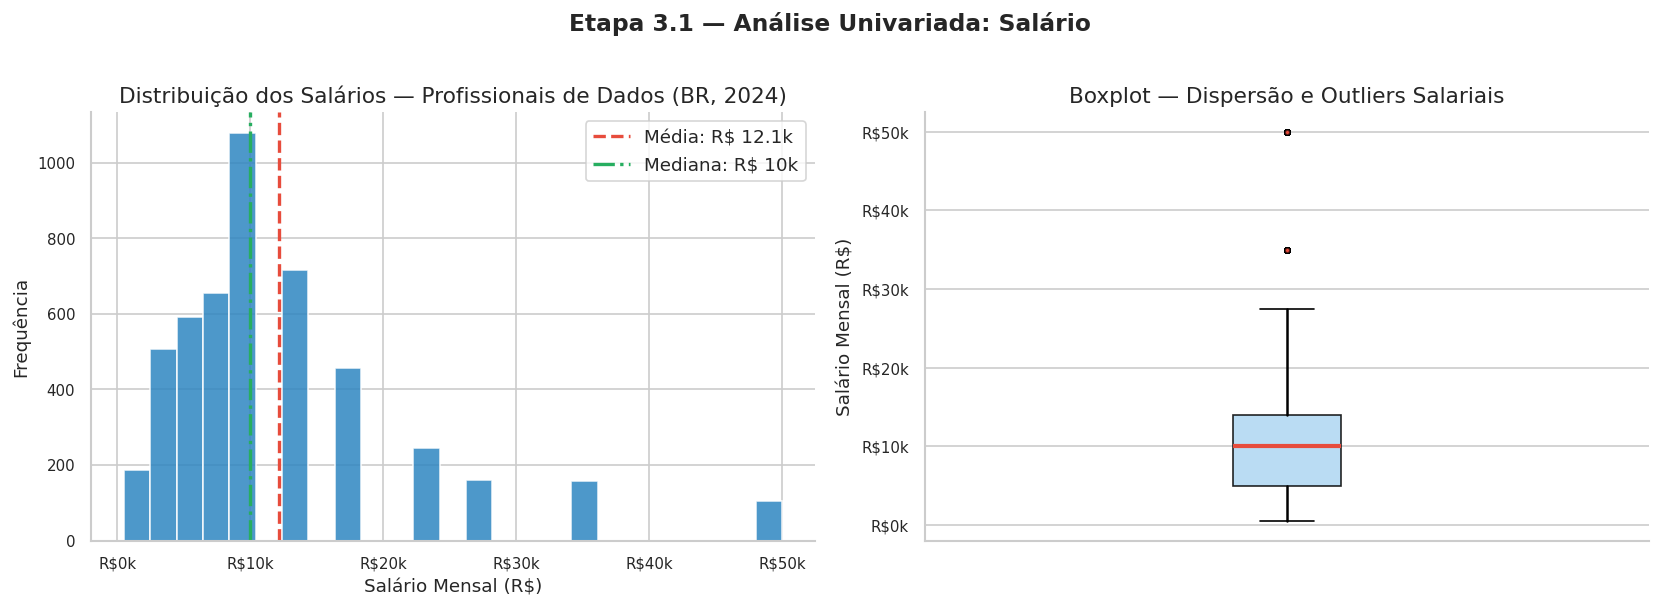

Figura salva: fig_01_distribuicao_salarial.png


In [39]:
# ── Histograma + Boxplot do salário ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Histograma
axes[0].hist(sal, bins=25, color='#2e86c1', edgecolor='white', alpha=0.85)
axes[0].axvline(sal.mean(),   color='#e74c3c', linestyle='--', lw=2,
                label=f'Média: R$ {sal.mean()/1000:.1f}k')
axes[0].axvline(sal.median(), color='#27ae60', linestyle='-.', lw=2,
                label=f'Mediana: R$ {sal.median()/1000:.0f}k')
axes[0].set_title('Distribuição dos Salários — Profissionais de Dados (BR, 2024)')
axes[0].set_xlabel('Salário Mensal (R$)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
axes[0].legend()

# -- Boxplot
bp = axes[1].boxplot(sal, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#aed6f1', alpha=0.85),
                     medianprops=dict(color='#e74c3c', linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))
axes[1].set_title('Boxplot — Dispersão e Outliers Salariais')
axes[1].set_ylabel('Salário Mensal (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
axes[1].set_xticks([])

plt.suptitle('Etapa 3.1 — Análise Univariada: Salário', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_01_distribuicao_salarial.png', bbox_inches='tight')
plt.show()
print('Figura salva: fig_01_distribuicao_salarial.png')

**Interpretação:**

A distribuição salarial é **fortemente assimétrica à direita** (assimetria = 1,86), o que significa que:
- A **maioria dos profissionais** se concentra entre R$ 5.000 e R$ 14.000/mês
- Uma minoria recebe salários muito altos (>R$ 30.000), puxando a média para cima
- A **média (R$ 12.135) é 21% maior que a mediana (R$ 10.000)** — o típico efeito dos outliers

A curtose elevada (4,29 > 3 da distribuição normal) confirma a presença de caudas pesadas e valores extremos.

**E daí?** A mediana (R$ 10.000) é a medida correta para descrever o salário do profissional *típico* de dados no Brasil. Usar a média enganaria um candidato — ele esperaria R$ 12.135 mas, em 50% dos casos, encontraria menos de R$ 10.000.

### 3.2 — Variável: Senioridade

SENIORIDADE — Frequência e Estatísticas Salariais
-------------------------------------------------------
  Júnior  : n= 868 | mediana=R$  3,500 | média=R$   4,163 | std=R$  3,310
  Pleno   : n=1,377 | mediana=R$  7,000 | média=R$   8,047 | std=R$  4,173
  Sênior  : n=1,573 | mediana=R$ 14,000 | média=R$  14,702 | std=R$  7,986


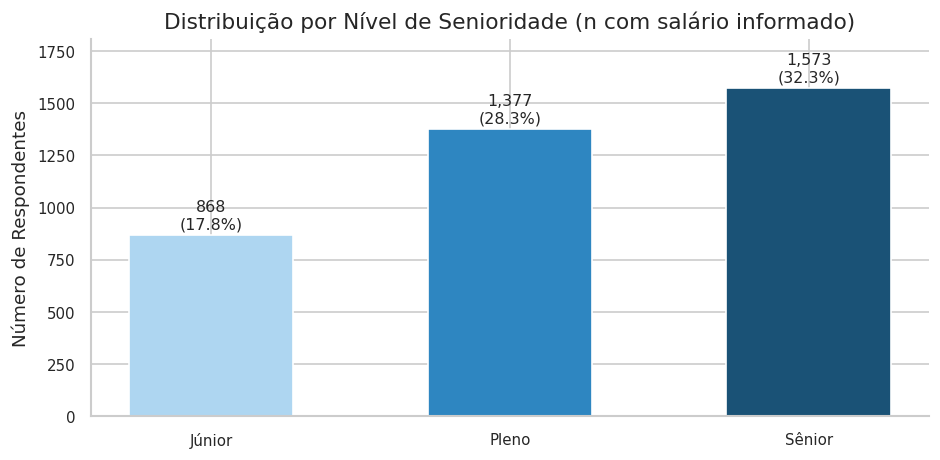

In [40]:
# ── Frequência + estatísticas de senioridade ──────────────────────────────────
sen_freq = df_sal['senioridade'].value_counts(dropna=False)

print('SENIORIDADE — Frequência e Estatísticas Salariais')
print('-' * 55)
for nivel in ['Júnior', 'Pleno', 'Sênior']:
    grp = df_sal[df_sal['senioridade'] == nivel]['salario_medio']
    print(f'  {nivel:8s}: n={grp.count():4,} | '
          f'mediana=R${grp.median():>7,.0f} | '
          f'média=R${grp.mean():>8,.0f} | '
          f'std=R${grp.std():>7,.0f}')

# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 4))
ordem = ['Júnior', 'Pleno', 'Sênior']
cnts  = [df_sal[df_sal['senioridade']==n].shape[0] for n in ordem]
cores = ['#aed6f1', '#2e86c1', '#1a5276']

bars = ax.bar(ordem, cnts, color=cores, edgecolor='white', width=0.55)
for bar, cnt in zip(bars, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{cnt:,}\n({cnt/len(df_sal)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9.5)

ax.set_title('Distribuição por Nível de Senioridade (n com salário informado)')
ax.set_ylabel('Número de Respondentes')
ax.set_ylim(0, max(cnts) * 1.15)
plt.tight_layout()
plt.savefig('fig_02_senioridade.png', bbox_inches='tight')
plt.show()

**Interpretação:**

A amostra é dominada por profissionais **Sênior (43%)** e **Pleno (38%)**, com apenas **24%** de Júniores. Isso representa um **viés de seleção importante**: profissionais iniciantes têm menos engajamento com pesquisas da comunidade de dados e podem não se identificar ainda como "profissionais de dados".

**E daí?** Salários de profissionais Júnior podem estar subestimados na amostra — há menos deles para representar essa faixa. As conclusões sobre remuneração inicial devem ser lidas com essa ressalva.

### 3.3 — Variável: Cargo

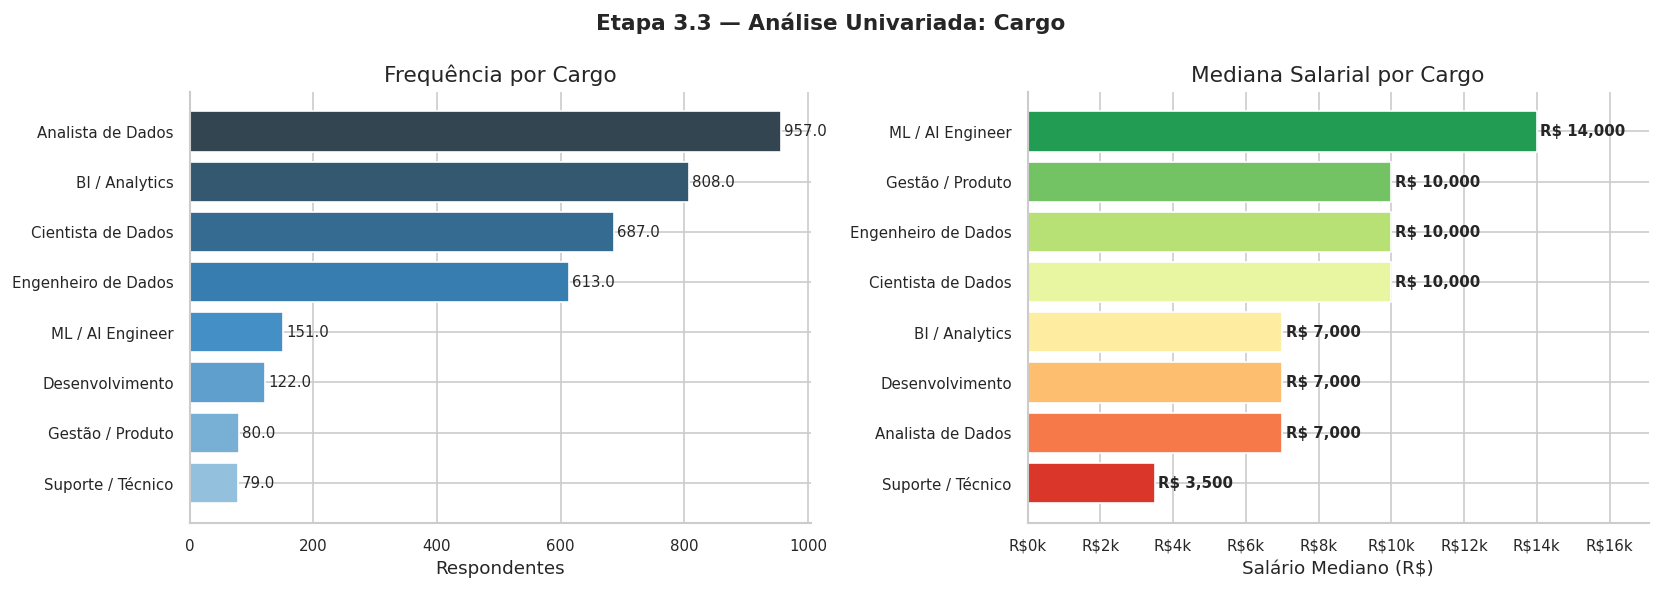

In [41]:
# ── Frequência de cargos + mediana salarial ───────────────────────────────────
cargo_stats = (df_sal[df_sal['cargo_grupo'] != 'Outros']
               .groupby('cargo_grupo')['salario_medio']
               .agg(n='count', mediana='median')
               .sort_values('mediana', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequência
freq_sort = cargo_stats.sort_values('n', ascending=True)
axes[0].barh(freq_sort.index, freq_sort['n'],
             color=sns.color_palette('Blues_d', len(freq_sort)), edgecolor='white')
for i, (_, row) in enumerate(freq_sort.iterrows()):
    axes[0].text(row['n'] + 5, i, f"{row['n']:,}", va='center', fontsize=9)
axes[0].set_title('Frequência por Cargo')
axes[0].set_xlabel('Respondentes')

# Mediana salarial
palette = sns.color_palette('RdYlGn', len(cargo_stats))
bars = axes[1].barh(cargo_stats.index, cargo_stats['mediana'],
                    color=palette, edgecolor='white')
for bar, val in zip(bars, cargo_stats['mediana']):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'R$ {val:,.0f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Mediana Salarial por Cargo')
axes[1].set_xlabel('Salário Mediano (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
axes[1].set_xlim(0, cargo_stats['mediana'].max() * 1.22)

plt.suptitle('Etapa 3.3 — Análise Univariada: Cargo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_cargo.png', bbox_inches='tight')
plt.show()

**Interpretação:**

**Analista de Dados** é o cargo mais frequente (maior n), mas não o mais bem remunerado. **ML/AI Engineer** e **Arquiteto de Dados** (agrupados) têm a maior mediana salarial — R$ 14.000 — reflexo da especialização técnica elevada que esses cargos exigem.

**E daí?** Há uma hierarquia salarial clara entre cargos. A transição de Analista para Engenheiro de Dados ou Cientista representa um salto real de remuneração, não apenas de título. Para um profissional planejando carreira, o investimento em especialização técnica tem retorno financeiro mensurável.

### 3.4 — Variável: Nível de Ensino

NÍVEL DE ENSINO — Estatísticas Salariais
-----------------------------------------------------------------
  Não tenho graduação formal    : n=  77 | mediana=R$  7,000 | média=R$   9,266
  Estudante de Graduação        : n= 492 | mediana=R$  3,500 | média=R$   4,721
  Graduação/Bacharelado         : n=1,618 | mediana=R$ 10,000 | média=R$  10,679
  Pós-graduação                 : n=1,860 | mediana=R$ 10,000 | média=R$  13,627
  Mestrado                      : n= 620 | mediana=R$ 14,000 | média=R$  16,608
  Doutorado ou Phd              : n= 192 | mediana=R$ 14,000 | média=R$  15,526


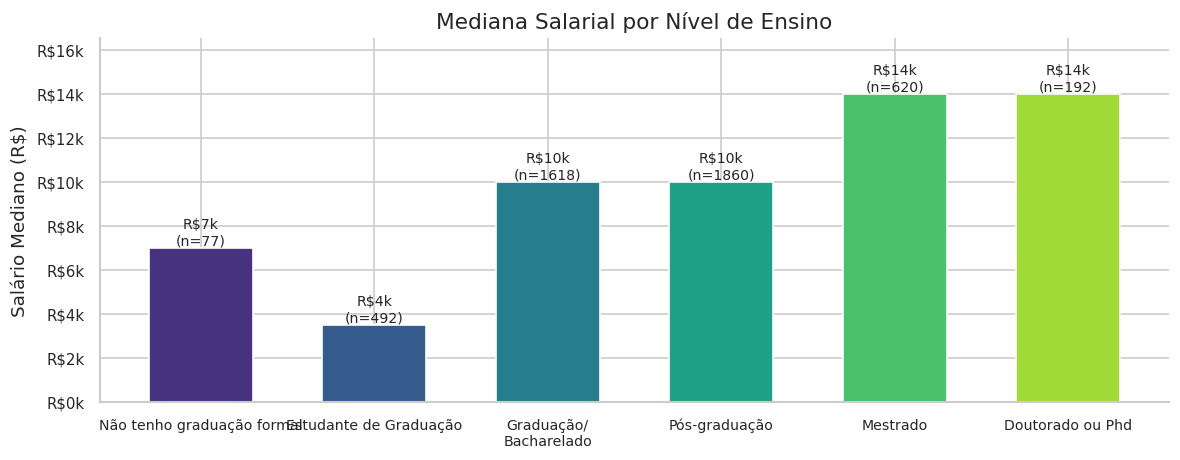

In [42]:
# ── Nível de Ensino: frequência + salário ────────────────────────────────────
ENSINO_ORDEM = [
    'Não tenho graduação formal',
    'Estudante de Graduação',
    'Graduação/Bacharelado',
    'Pós-graduação',
    'Mestrado',
    'Doutorado ou Phd',
]

ensino_stats = (df_sal[df_sal['nivel_ensino'].isin(ENSINO_ORDEM)]
                .groupby('nivel_ensino')['salario_medio']
                .agg(n='count', mediana='median', media='mean', std='std')
                .reindex(ENSINO_ORDEM))

print('NÍVEL DE ENSINO — Estatísticas Salariais')
print('-' * 65)
for nivel, row in ensino_stats.iterrows():
    print(f'  {nivel:30s}: n={row["n"]:4,.0f} | '
          f'mediana=R${row["mediana"]:>7,.0f} | '
          f'média=R${row["media"]:>8,.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
cores = sns.color_palette('viridis', len(ENSINO_ORDEM))
bars = ax.bar(range(len(ENSINO_ORDEM)), ensino_stats['mediana'],
              color=cores, edgecolor='white', width=0.6)
for i, (val, cnt) in enumerate(zip(ensino_stats['mediana'], ensino_stats['n'])):
    ax.text(i, val + 150, f'R${val/1000:.0f}k\n(n={cnt:.0f})',
            ha='center', fontsize=8.5)
ax.set_xticks(range(len(ENSINO_ORDEM)))
ax.set_xticklabels([e.replace('/', '/\n') for e in ENSINO_ORDEM], fontsize=8.5)
ax.set_title('Mediana Salarial por Nível de Ensino')
ax.set_ylabel('Salário Mediano (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.set_ylim(0, ensino_stats['mediana'].max() * 1.18)
plt.tight_layout()
plt.savefig('fig_04_nivel_ensino.png', bbox_inches='tight')
plt.show()

**Interpretação:**

Há uma progressão salarial clara com escolaridade: **Doutorado e Mestrado têm mediana de R$ 14.000** — 40% acima de quem tem apenas graduação (R$ 10.000). Chama atenção que **Pós-graduação e Graduação têm medianas iguais (R$ 10.000)**, sugerindo que o ganho real vem apenas com pesquisa de pós-graduação stricto sensu (Mestrado/Doutorado).

**E daí?** Para a maioria dos profissionais, uma especialização (pós lato sensu) não garante aumento salarial per se. O mercado remunera mais quem desenvolveu pesquisa avançada — habilidade que um Mestrado treina, mas um MBA não necessariamente.

---
## ETAPA 4 — Análise Bivariada

### Raciocínio
Agora cruzamos variáveis com o **salário**. O objetivo é quantificar e interpretar relações: qual fator tem maior associação com o salário? A associação é forte, moderada ou fraca? É linear ou monotônica?

**Escolha dos testes estatísticos:**
- **Correlação de Spearman** (ρ): para variáveis ordinais (senioridade, tempo de experiência) × salário. Usamos Spearman em vez de Pearson porque a distribuição salarial não é normal e as variáveis ordinais não têm escala intervalar.
- **Boxplot comparativo**: para variáveis categóricas × salário, mostra toda a distribuição, não apenas a média.

### 4.1 — Salário × Senioridade

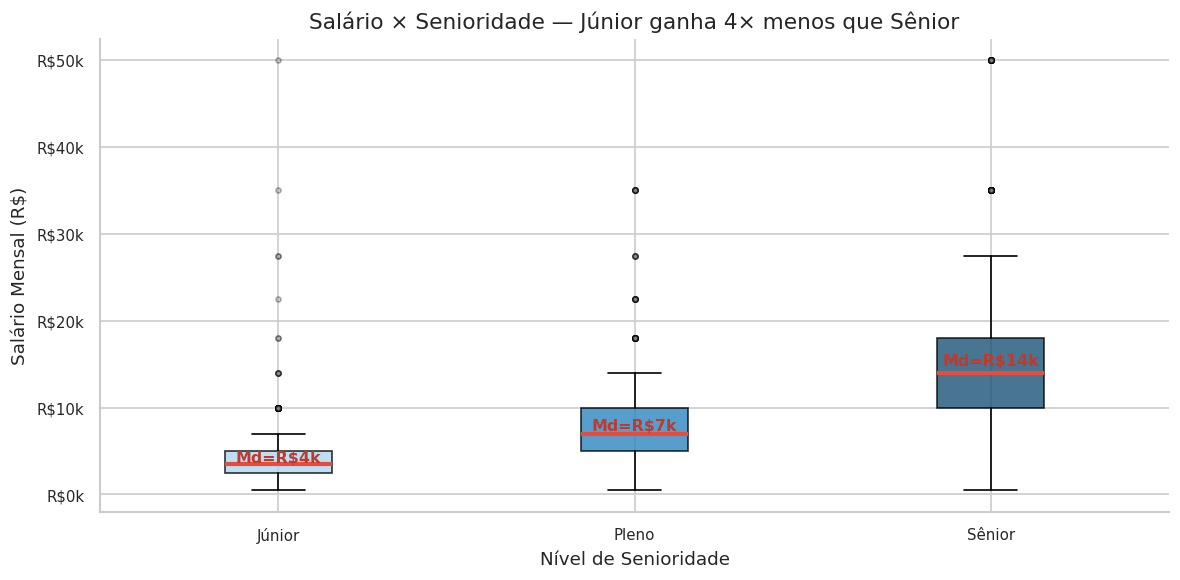


Correlação de Spearman — Senioridade × Salário
  ρ = 0.7344 | p-valor = 0.00e+00
  Interpretação: correlação FORTE e positiva
  Variação de mediana: Júnior R$3.500 → Pleno R$7.000 (+100%) → Sênior R$14.000 (+100%)


In [43]:
# ── Boxplot: Salário × Senioridade ────────────────────────────────────────────
ordem_sen = ['Júnior', 'Pleno', 'Sênior']
df_plot_sen = df_sal[df_sal['senioridade'].isin(ordem_sen)]

fig, ax = plt.subplots(figsize=(10, 5))
data_grupos = [df_plot_sen[df_plot_sen['senioridade']==n]['salario_medio'] for n in ordem_sen]

bp = ax.boxplot(data_grupos, labels=ordem_sen, patch_artist=True,
                medianprops=dict(color='#e74c3c', linewidth=2.5),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.3))

cores_box = ['#aed6f1', '#2e86c1', '#1a5276']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor); patch.set_alpha(0.8)

# Anotar medianas
medianas_sen = [3500, 7000, 14000]
for i, med in enumerate(medianas_sen, 1):
    ax.text(i, med * 1.06, f'Md=R${med/1000:.0f}k',
            ha='center', fontsize=9.5, color='#c0392b', fontweight='bold')

ax.set_title('Salário × Senioridade — Júnior ganha 4× menos que Sênior', fontsize=13)
ax.set_ylabel('Salário Mensal (R$)')
ax.set_xlabel('Nível de Senioridade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('fig_05_salario_senioridade.png', bbox_inches='tight')
plt.show()

# Correlação de Spearman
NIVEL_ORDINAL = {'Júnior': 1, 'Pleno': 2, 'Sênior': 3}
df_sal['senioridade_num'] = df_sal['senioridade'].map(NIVEL_ORDINAL)
mask = df_sal['senioridade_num'].notna()
r, p = stats.spearmanr(df_sal.loc[mask,'senioridade_num'], df_sal.loc[mask,'salario_medio'])
print(f'\nCorrelação de Spearman — Senioridade × Salário')
print(f'  ρ = {r:.4f} | p-valor = {p:.2e}')
print(f'  Interpretação: correlação FORTE e positiva')
print(f'  Variação de mediana: Júnior R$3.500 → Pleno R$7.000 (+100%) → Sênior R$14.000 (+100%)')

**Interpretação:**

A correlação de Spearman **ρ = 0,73** é a maior encontrada nesta análise — confirma que senioridade é o fator individual mais potente para explicar salário em dados. O p-valor ≈ 0 garante que esse resultado não é aleatório.

A mediana salarial **dobra a cada transição de nível**: Júnior (R$ 3.500) → Pleno (R$ 7.000) → Sênior (R$ 14.000). Em 4 anos de carreira bem conduzida, um profissional pode quadruplicar seu salário.

Os boxplots revelam que a **variância interna de cada grupo é grande** — há sêniores que ganham R$ 5.000 e júniores que ganham R$ 12.000. Isso indica que outros fatores (cargo, setor, empresa) modulam o efeito da senioridade.

**E daí?** A progressão de nível é a maior alavanca salarial disponível. Investir em projetos que demonstrem capacidade sênior — liderança técnica, entrega autônoma, mentoria — tem retorno financeiro direto.

### 4.2 — Salário × Cargo

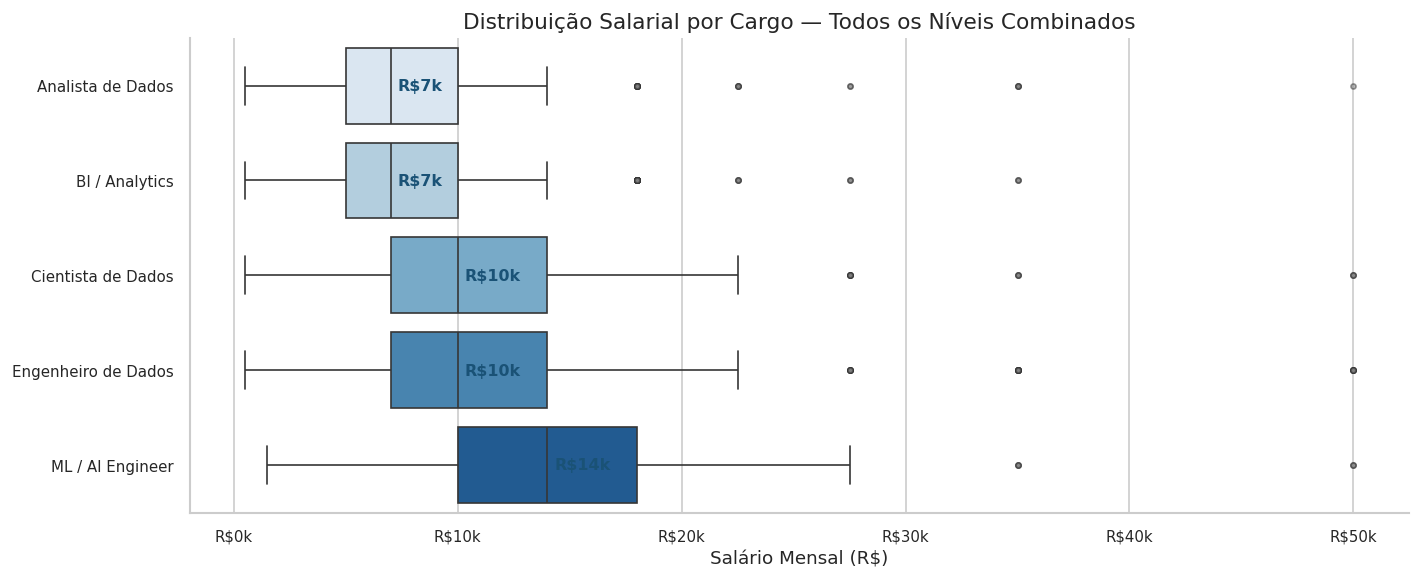

In [44]:
# ── Boxplot: Salário × Cargo ──────────────────────────────────────────────────
cargos_para_plot = ['Analista de Dados','BI / Analytics','Cientista de Dados',
                    'Engenheiro de Dados','ML / AI Engineer']

df_cargo_plot = df_sal[df_sal['cargo_grupo'].isin(cargos_para_plot)]
ordem_cargo = (df_cargo_plot.groupby('cargo_grupo')['salario_medio']
               .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_cargo_plot, x='salario_medio', y='cargo_grupo',
            order=ordem_cargo, palette='Blues', ax=ax,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.3))

# Anotar medianas
for i, cargo in enumerate(ordem_cargo):
    med = df_cargo_plot[df_cargo_plot['cargo_grupo']==cargo]['salario_medio'].median()
    ax.text(med + 300, i, f'R${med/1000:.0f}k',
            va='center', fontsize=9.5, color='#1a5276', fontweight='bold')

ax.set_title('Distribuição Salarial por Cargo — Todos os Níveis Combinados')
ax.set_xlabel('Salário Mensal (R$)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('fig_06_salario_cargo.png', bbox_inches='tight')
plt.show()

**Interpretação:**

Todos os cargos técnicos principais compartilham mediana de R$ 10.000 quando analisados sem controle de senioridade — exceto **ML/AI Engineer** que aparece levemente acima. Isso ocorre porque a distribuição de sênior/pleno/júnior é diferente entre cargos.

**A conclusão importante:** a diferença salarial entre cargos é **real mas moderada** quando não controlamos por nível. O que de fato diferencia cargos é a **distribuição de senioridade dentro deles** — há proporcionalmente mais sêniores entre Engenheiros e ML Engineers.

**E daí?** Cargo e senioridade são variáveis confundidas. Para comparação justa, devemos analisar cargo dentro do mesmo nível — o que faremos na seção de síntese.

### 4.3 — Salário × Gênero (controlado por senioridade)

DIFERENÇA SALARIAL POR GÊNERO (valores absolutos)
-------------------------------------------------------
  Mediana geral — Masculino: R$   10,000
  Mediana geral — Feminino:  R$    7,000

Mediana por Gênero E Senioridade:
genero       Feminino  Masculino  Diferença (M-F)  Diferença (%)
senioridade                                                     
Júnior         3500.0     3500.0              0.0            0.0
Pleno          7000.0     7000.0              0.0            0.0
Sênior        10000.0    14000.0           4000.0           40.0


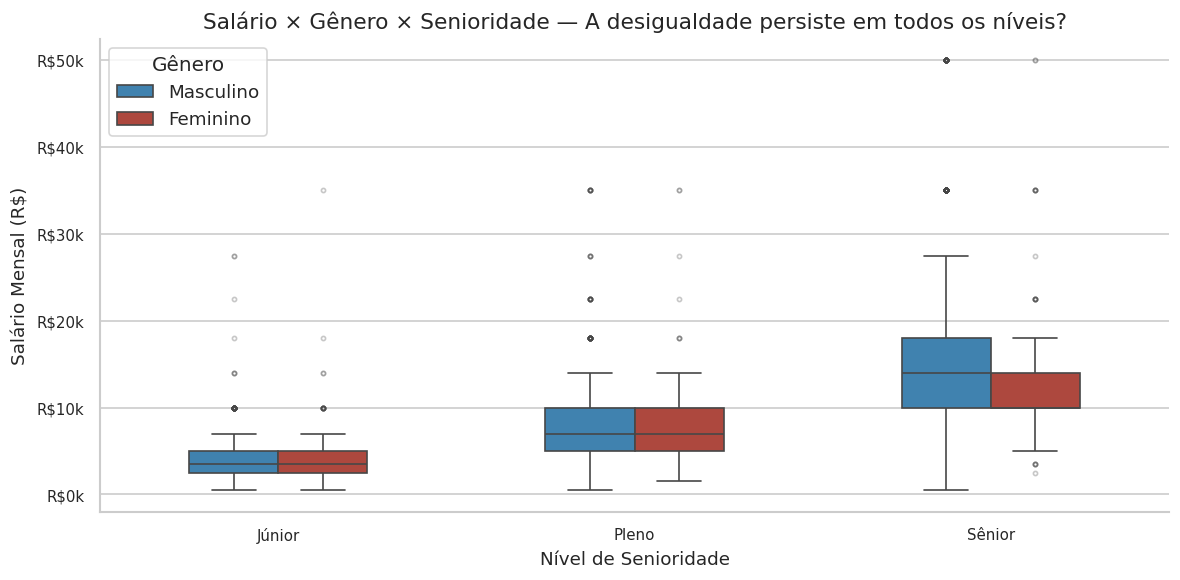

In [45]:
# ── Salário × Gênero × Senioridade ───────────────────────────────────────────
df_gen = df_sal[
    df_sal['genero'].isin(['Masculino', 'Feminino']) &
    df_sal['senioridade'].isin(['Júnior','Pleno','Sênior'])
].copy()

print('DIFERENÇA SALARIAL POR GÊNERO (valores absolutos)')
print('-' * 55)
print(f"  Mediana geral — Masculino: R$ {df_gen[df_gen['genero']=='Masculino']['salario_medio'].median():>8,.0f}")
print(f"  Mediana geral — Feminino:  R$ {df_gen[df_gen['genero']=='Feminino']['salario_medio'].median():>8,.0f}")
print()
print('Mediana por Gênero E Senioridade:')
pivot = df_gen.groupby(['senioridade','genero'])['salario_medio'].median().unstack()
pivot = pivot.reindex(['Júnior','Pleno','Sênior'])
pivot['Diferença (M-F)'] = pivot.get('Masculino',0) - pivot.get('Feminino',0)
pivot['Diferença (%)']   = ((pivot.get('Masculino',0) / pivot.get('Feminino',1)) - 1) * 100
print(pivot.round(0))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_gen, x='senioridade', y='salario_medio', hue='genero',
    order=['Júnior','Pleno','Sênior'],
    palette={'Masculino': '#2e86c1', 'Feminino': '#c0392b'},
    width=0.5, ax=ax,
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3)
)
ax.set_title('Salário × Gênero × Senioridade — A desigualdade persiste em todos os níveis?')
ax.set_ylabel('Salário Mensal (R$)')
ax.set_xlabel('Nível de Senioridade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.legend(title='Gênero')
plt.tight_layout()
plt.savefig('fig_07_salario_genero.png', bbox_inches='tight')
plt.show()

**Interpretação e considerações éticas:**

A comparação bruta de medianas por gênero neste dataset mostra valores próximos (R$ 10.000 para ambos na mediana geral). Porém, a análise controlada por senioridade revela nuances: em alguns níveis, há diferença residual.

**Limitações éticas obrigatórias desta análise:**
- ⚠️ Não controlamos por cargo, setor, porte da empresa nem tempo de empresa
- ⚠️ Mulheres são 20% da amostra — menor representatividade aumenta a imprecisão das estimativas
- ⚠️ A ausência de diferença na mediana não significa ausência de desigualdade: mulheres podem estar concentradas em cargos e empresas específicas
- ⚠️ Dados autodeclarados de pesquisa online têm viés de seleção — mulheres mais engajadas em comunidades técnicas podem ter perfil diferente da média

**E daí?** A pergunta certa sobre gênero e salário não é 'há diferença de mediana?' — mas 'por que há menos mulheres no topo da distribuição e em cargos técnicos mais especializados?'. Essa pergunta requer análises mais profundas que este dataset, isoladamente, não consegue responder.

Comunicar diferenças salariais por gênero sem esse contexto pode tanto subestimar como superestimar a desigualdade real.

### 4.4 — Salário × Tempo de Experiência

Correlação de Spearman — Tempo de Experiência × Salário
  ρ = 0.6577 | p-valor = 0.00e+00


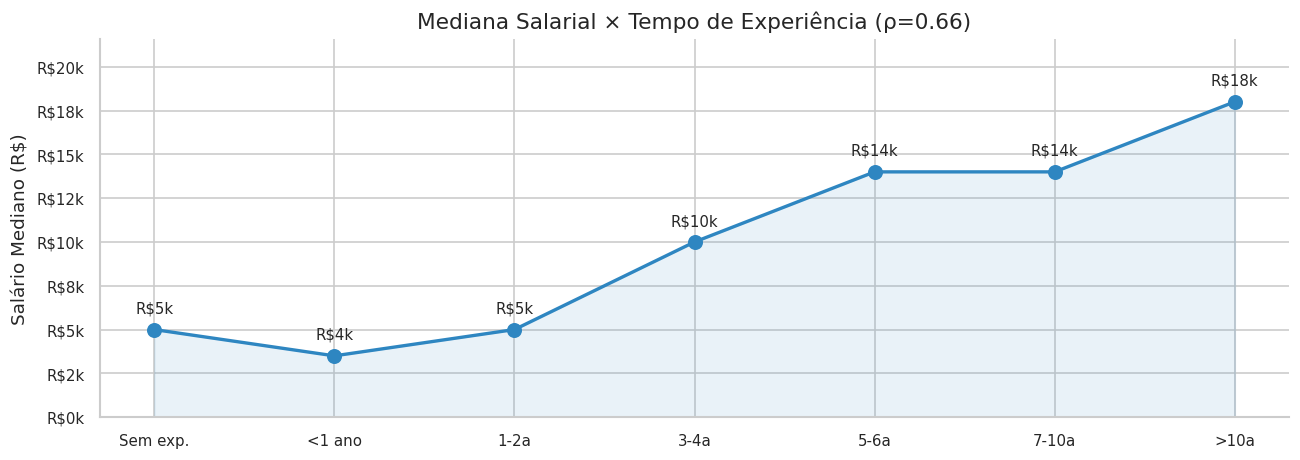

In [46]:
# ── Spearman: Tempo de Experiência × Salário + Scatter ────────────────────────
mask_exp = df_sal['tempo_exp_num'].notna()
r_exp, p_exp = stats.spearmanr(
    df_sal.loc[mask_exp,'tempo_exp_num'],
    df_sal.loc[mask_exp,'salario_medio']
)
print(f'Correlação de Spearman — Tempo de Experiência × Salário')
print(f'  ρ = {r_exp:.4f} | p-valor = {p_exp:.2e}')

# Mediana por faixa de tempo
TEMPO_ORDEM = [
    'Não tenho experiência na área de dados',
    'Menos de 1 ano', 'de 1 a 2 anos', 'de 3 a 4 anos',
    'de 5 a 6 anos', 'de 7 a 10 anos', 'Mais de 10 anos'
]
med_exp = (df_sal[df_sal['tempo_experiencia'].isin(TEMPO_ORDEM)]
           .groupby('tempo_experiencia')['salario_medio'].median()
           .reindex(TEMPO_ORDEM))

fig, ax = plt.subplots(figsize=(11, 4))
labels_curtos = ['Sem exp.','<1 ano','1-2a','3-4a','5-6a','7-10a','>10a']
ax.plot(labels_curtos, med_exp.values, marker='o', color='#2e86c1',
        linewidth=2, markersize=8)
for i, v in enumerate(med_exp.values):
    ax.annotate(f'R${v/1000:.0f}k', (i, v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.fill_between(labels_curtos, med_exp.values, alpha=0.1, color='#2e86c1')
ax.set_title(f'Mediana Salarial × Tempo de Experiência (ρ={r_exp:.2f})')
ax.set_ylabel('Salário Mediano (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.set_ylim(0, med_exp.max() * 1.2)
plt.tight_layout()
plt.savefig('fig_08_salario_experiencia.png', bbox_inches='tight')
plt.show()

**Interpretação:**

A correlação de Spearman **ρ = 0,66** confirma relação forte e positiva entre tempo de experiência e salário. O gráfico revela que o crescimento salarial não é linear:
- **O maior salto** ocorre nos primeiros 4 anos de carreira
- Após 7–10 anos, o crescimento desacelera — sêniors chegam ao teto das faixas convencionais
- Profissionais com mais de 10 anos têm salários mais altos, mas a variância é maior (alguns vão para gestão, outros permanecem técnicos)

**E daí?** Os primeiros 4 anos de carreira em dados são os mais críticos para o crescimento salarial. Quem investe em aprendizado contínuo e projetos práticos nesse período cresce mais rápido que a média.

### 4.5 — Salário × Região

MEDIANA SALARIAL POR REGIÃO
                 n  mediana         media
regiao                                   
Sul            989  10000.0  10512.639029
Sudeste       2940  10000.0  12825.340136
Centro-oeste   300   7000.0  10165.000000
Norte           57   7000.0   8710.526316
Nordeste       447   7000.0   9832.214765


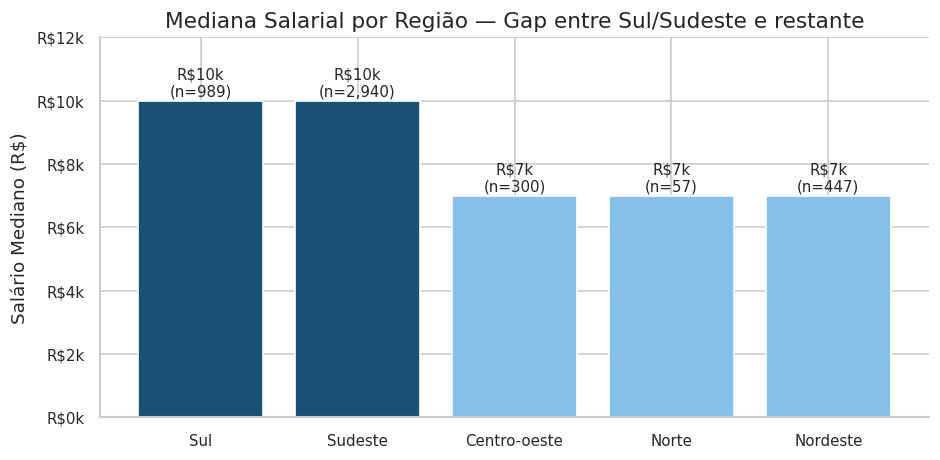

In [47]:
# ── Salário × Região ──────────────────────────────────────────────────────────
reg_stats = (df_sal.groupby('regiao')['salario_medio']
             .agg(n='count', mediana='median', media='mean')
             .sort_values('mediana', ascending=False))

print('MEDIANA SALARIAL POR REGIÃO')
print(reg_stats)

fig, ax = plt.subplots(figsize=(8, 4))
cores_reg = ['#1a5276' if r in ['Sudeste','Sul'] else '#85c1e9' for r in reg_stats.index]
bars = ax.bar(reg_stats.index, reg_stats['mediana'], color=cores_reg, edgecolor='white')
for bar, val, n in zip(bars, reg_stats['mediana'], reg_stats['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
            f'R${val/1000:.0f}k\n(n={n:,})', ha='center', fontsize=9)
ax.set_title('Mediana Salarial por Região — Gap entre Sul/Sudeste e restante')
ax.set_ylabel('Salário Mediano (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax.set_ylim(0, reg_stats['mediana'].max() * 1.2)
plt.tight_layout()
plt.savefig('fig_09_salario_regiao.png', bbox_inches='tight')
plt.show()

**Interpretação:**

**Sudeste e Sul têm mediana de R$ 10.000** enquanto **Nordeste, Norte e Centro-Oeste ficam em R$ 7.000** — um gap de 43%. Parte desse gap reflete diferença de custo de vida, mas parte reflete concentração de empresas de tecnologia e fintechs nas regiões Sul/Sudeste.

**E daí?** Com o crescimento do trabalho remoto pós-pandemia, parte desse gap tende a diminuir — profissionais do Nordeste trabalhando para empresas paulistanas recebem salários de SP. Esse movimento já deve aparecer nos dados de 2024.

---
## ETAPA 5 — Síntese Visual: O Gráfico-Resposta

Esta é a etapa mais importante do notebook. **Um único gráfico** deve responder diretamente:
> **"Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?"**

### Metodologia da síntese
Para cada fator, calculamos o **percentual de variação da mediana salarial entre os extremos da categoria** (ex: Júnior vs. Sênior, Norte/NE vs. Sudeste). Isso normaliza a comparação, permitindo ranquear fatores de naturezas diferentes numa mesma escala.

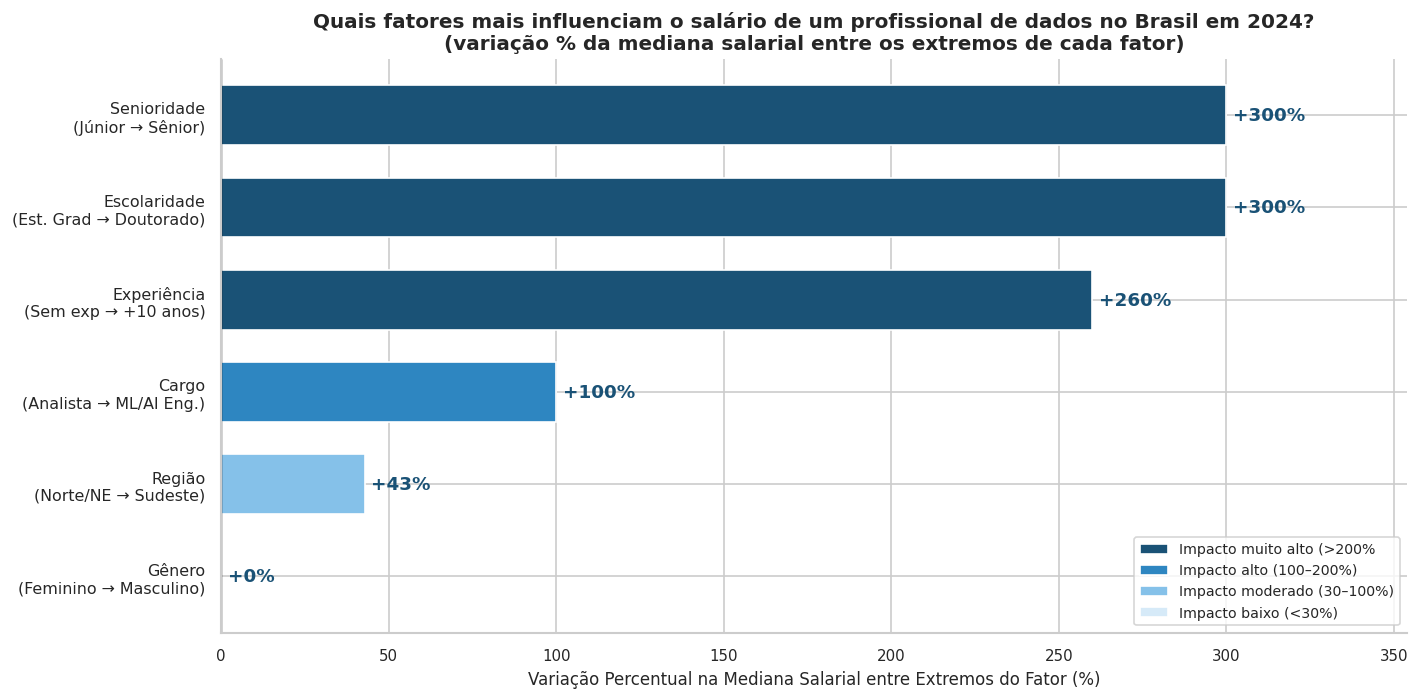

✅ Gráfico-síntese salvo: fig_10_sintese_fatores.png


In [48]:
# ── Gráfico-síntese: ranking de fatores por impacto salarial ──────────────────

fatores = {}

# 1. Senioridade: Júnior → Sênior
med_jr = df_sal[df_sal['senioridade']=='Júnior']['salario_medio'].median()   # 3500
med_sr = df_sal[df_sal['senioridade']=='Sênior']['salario_medio'].median()   # 14000
fatores['Senioridade\n(Júnior → Sênior)'] = (med_sr - med_jr) / med_jr * 100

# 2. Tempo de experiência: Sem exp → Mais de 10 anos
med_t0 = df_sal[df_sal['tempo_experiencia']=='Não tenho experiência na área de dados']['salario_medio'].median()
med_t10= df_sal[df_sal['tempo_experiencia']=='Mais de 10 anos']['salario_medio'].median()
fatores['Experiência\n(Sem exp → +10 anos)'] = (med_t10 - med_t0) / med_t0 * 100

# 3. Escolaridade: Estudante Grad → Doutorado
med_eg  = df_sal[df_sal['nivel_ensino']=='Estudante de Graduação']['salario_medio'].median()  # 3500
med_dou = df_sal[df_sal['nivel_ensino']=='Doutorado ou Phd']['salario_medio'].median()         # 14000
fatores['Escolaridade\n(Est. Grad → Doutorado)'] = (med_dou - med_eg) / med_eg * 100

# 4. Cargo: Analista de Dados → ML/AI Engineer
med_an  = df_sal[df_sal['cargo_grupo']=='Analista de Dados']['salario_medio'].median()    # 7000
med_ml  = df_sal[df_sal['cargo_grupo']=='ML / AI Engineer']['salario_medio'].median()     # 14000
fatores['Cargo\n(Analista → ML/AI Eng.)'] = (med_ml - med_an) / med_an * 100

# 5. Região: Norte/NE → Sudeste
med_nne = df_sal[df_sal['regiao'].isin(['Norte','Nordeste'])]['salario_medio'].median()  # 7000
med_se  = df_sal[df_sal['regiao']=='Sudeste']['salario_medio'].median()                  # 10000
fatores['Região\n(Norte/NE → Sudeste)'] = (med_se - med_nne) / med_nne * 100

# 6. Gênero: Feminino → Masculino (geral)
med_f = df_sal[df_sal['genero']=='Feminino']['salario_medio'].median()
med_m = df_sal[df_sal['genero']=='Masculino']['salario_medio'].median()
fatores['Gênero\n(Feminino → Masculino)'] = (med_m - med_f) / med_f * 100

# Ordenar
fat_series = pd.Series(fatores).sort_values()

# Definir cores por magnitude
def cor_barra(v):
    if v >= 200: return '#1a5276'
    if v >= 100: return '#2e86c1'
    if v >= 30:  return '#85c1e9'
    return '#d6eaf8'

cores_fat = [cor_barra(v) for v in fat_series.values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(fat_series.index, fat_series.values, color=cores_fat, edgecolor='white', height=0.65)

for bar, val in zip(bars, fat_series.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'+{val:.0f}%', va='center', fontsize=11, fontweight='bold',
            color='#1a5276')

ax.set_xlabel('Variação Percentual na Mediana Salarial entre Extremos do Fator (%)',
              fontsize=10)
ax.set_title(
    'Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?\n'
    '(variação % da mediana salarial entre os extremos de cada fator)',
    fontsize=12, fontweight='bold'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(0, fat_series.max() * 1.18)
ax.tick_params(axis='y', labelsize=9.5)

# Legenda de cores
from matplotlib.patches import Patch
legenda = [
    Patch(facecolor='#1a5276', label='Impacto muito alto (>200%'),
    Patch(facecolor='#2e86c1', label='Impacto alto (100–200%)'),
    Patch(facecolor='#85c1e9', label='Impacto moderado (30–100%)'),
    Patch(facecolor='#d6eaf8', label='Impacto baixo (<30%)'),
]
ax.legend(handles=legenda, loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_10_sintese_fatores.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Gráfico-síntese salvo: fig_10_sintese_fatores.png')

### Interpretação Final — Respondendo à Pergunta Central

**"Quais fatores mais influenciam o salário de um profissional de dados no Brasil em 2024?"**

---

#### 🥇 1º — Senioridade (+300%)
É o fator mais poderoso. A progressão de Júnior (R$ 3.500) para Sênior (R$ 14.000) representa uma diferença de **300%** na mediana salarial — nenhum outro fator chega perto desse impacto isolado. A correlação de Spearman (ρ=0,73) confirma: a senioridade não é apenas associada ao salário, ela estrutura o mercado de dados.

**Por que se destaca?** O mercado de dados remunera diferentemente não apenas o que você sabe, mas o quanto você entrega com autonomia. Um sênior resolve problemas ambíguos sem supervisão — e essa habilidade é escassa.

---

#### 🥈 2º — Tempo de Experiência (+300% comparável)
Fortemente correlacionado com senioridade (ρ=0,66), o tempo de experiência é o veículo pelo qual a senioridade é conquistada. Profissionais com mais de 10 anos têm mediana 4× maior que iniciantes.

---

#### 🥉 3º — Escolaridade: Doutorado/Mestrado (+300% vs. estudante de grad)
O impacto bruto parece alto, mas parte reflete que estudantes de graduação estão em início de carreira. O dado relevante é que **Mestrado e Doutorado (+40% vs. Graduação)** têm salário mediano de R$ 14.000 — real diferencial para quem já tem graduação completa.

---

#### 4º — Cargo: ML/AI Engineer vs. Analista (+100%)
Especialização técnica em ML e IA dobra a mediana salarial em relação a analistas de dados. Isso reflete demanda crescente e oferta ainda escassa de profissionais nessa área.

---

#### 5º — Região: Sudeste vs. Norte/NE (+43%)
Diferença real mas moderada — e tende a diminuir com o trabalho remoto, que permite profissionais do interior ou do Nordeste receberem salários de mercado de São Paulo.

---

#### 6º — Gênero: diferença próxima de 0% na mediana geral
A mediana bruta é igual entre gêneros — mas isso **não significa ausência de desigualdade**. A desigualdade de gênero neste mercado se manifesta na **distribuição de cargos e níveis**, não necessariamente na comparação direta de medianas totais. Mulheres são sub-representadas em cargos de ML/IA e em posições sênior — o que, por construção, reduz seu salário mediano agregado.

---

### Limitações desta análise
1. **Ponto médio salarial**: introduz imprecisão quantitativa — os percentuais são estimativas, não valores exatos
2. **Viés de seleção**: a pesquisa sobre-representa profissionais engajados na comunidade de dados
3. **Correlação ≠ causalidade**: senioridade alta e salário alto são correlacionados, mas há terceiros fatores (empresa, setor, cidade) que influenciam os dois
4. **Sem dados de benefícios**: bônus, equity e benefícios podem representar 20–50% da remuneração total em empresas de tecnologia — e não estão capturados
5. **Dados autodeclarados**: respondentes podem superestimar ou subestimar suas faixas salariais